# IBM HR Analytics — Employee Attrition EDA

**Business Question:** Why are employees leaving, and which profiles are most at risk?

**Dataset:** IBM HR Analytics (1,470 employees · 35 features)  
**Source:** [Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

---
**Sections:**
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis
4. Numerical Features
5. Categorical Features
6. Correlation Analysis
7. Business Conclusions

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Color palette: left = stayed, right = left company
COLORS = {'No': '#4C72B0', 'Yes': '#DD8452'}

In [2]:
DATA_PATH = 'data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Dataset Overview

In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
No missing values found.


In [5]:
# Drop columns with zero variance (same value for all employees)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Constant columns removed: {constant_cols}')
df.drop(columns=constant_cols, inplace=True)

# Summary statistics
df.describe()

Constant columns removed: ['EmployeeCount', 'Over18', 'StandardHours']


,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 3. Target Variable — Attrition Rate

=== Attrition Summary ===
  No: 1,233 employees (83.9%)
  Yes: 237 employees (16.1%)


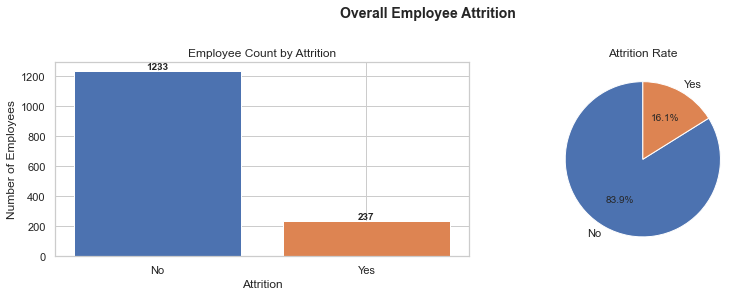

In [6]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print('=== Attrition Summary ===')
for label in ['No', 'Yes']:
    print(f'  {label}: {attrition_counts[label]:,} employees ({attrition_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=[COLORS[k] for k in attrition_counts.index])
axes[0].set_title('Employee Count by Attrition')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, (label, val) in enumerate(attrition_counts.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            colors=[COLORS[k] for k in attrition_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Attrition Rate')

plt.suptitle('Overall Employee Attrition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Numerical Features

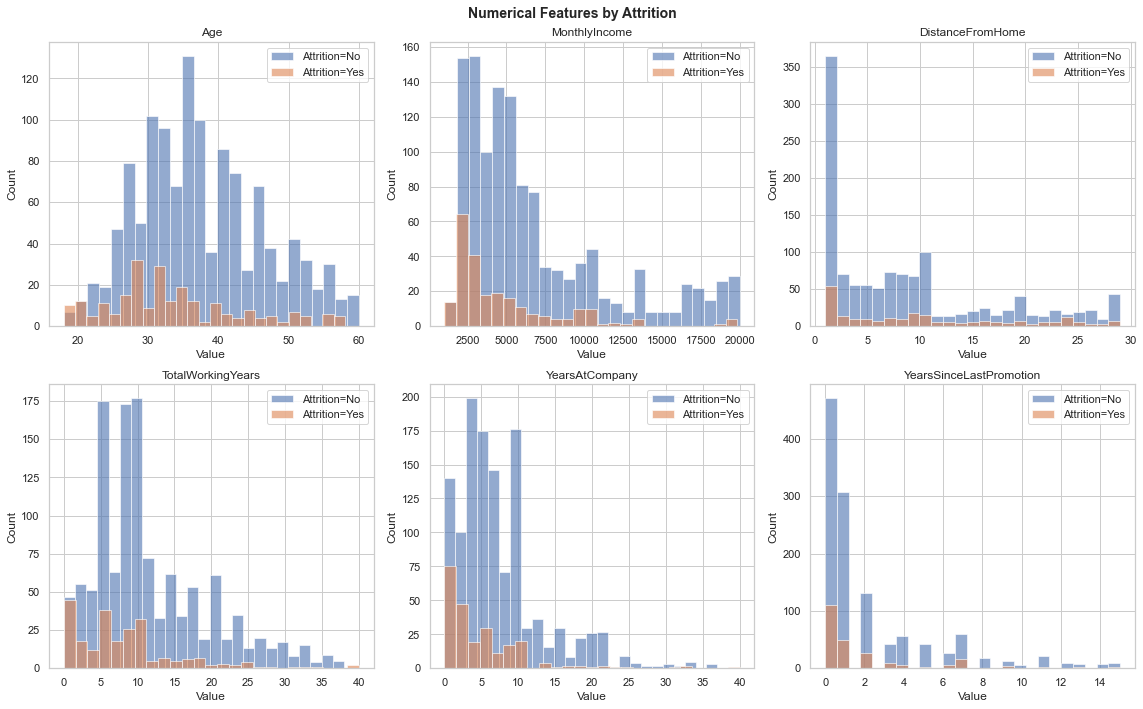

In [7]:
# Key numerical variables to explore
num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome',
            'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in COLORS.items():
        subset = df[df['Attrition'] == label][col]
        axes[i].hist(subset, alpha=0.6, bins=25, color=color, label=f'Attrition={label}')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Numerical Features by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

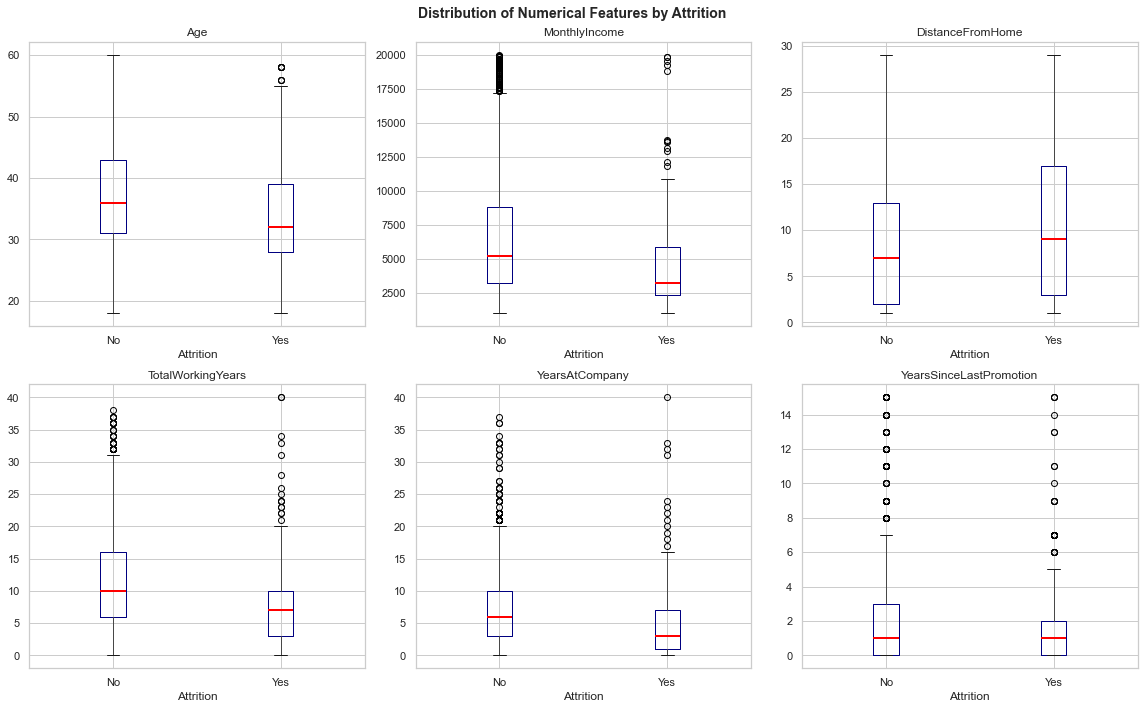

In [8]:
# Box plots for clearer comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Attrition', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('Attrition')

plt.suptitle('Distribution of Numerical Features by Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Mean comparison table: stayed vs left
mean_comparison = df.groupby('Attrition')[num_cols].mean().T
mean_comparison['Difference (%)'] = ((mean_comparison['Yes'] - mean_comparison['No']) / mean_comparison['No'] * 100).round(1)
mean_comparison.round(1)

Attrition,No,Yes,Difference (%)
Age,37.6,33.6,-10.5
MonthlyIncome,6832.7,4787.1,-29.9
DistanceFromHome,8.9,10.6,19.3
TotalWorkingYears,11.9,8.2,-30.5
YearsAtCompany,7.4,5.1,-30.4
YearsSinceLastPromotion,2.2,1.9,-12.9


## 5. Categorical Features

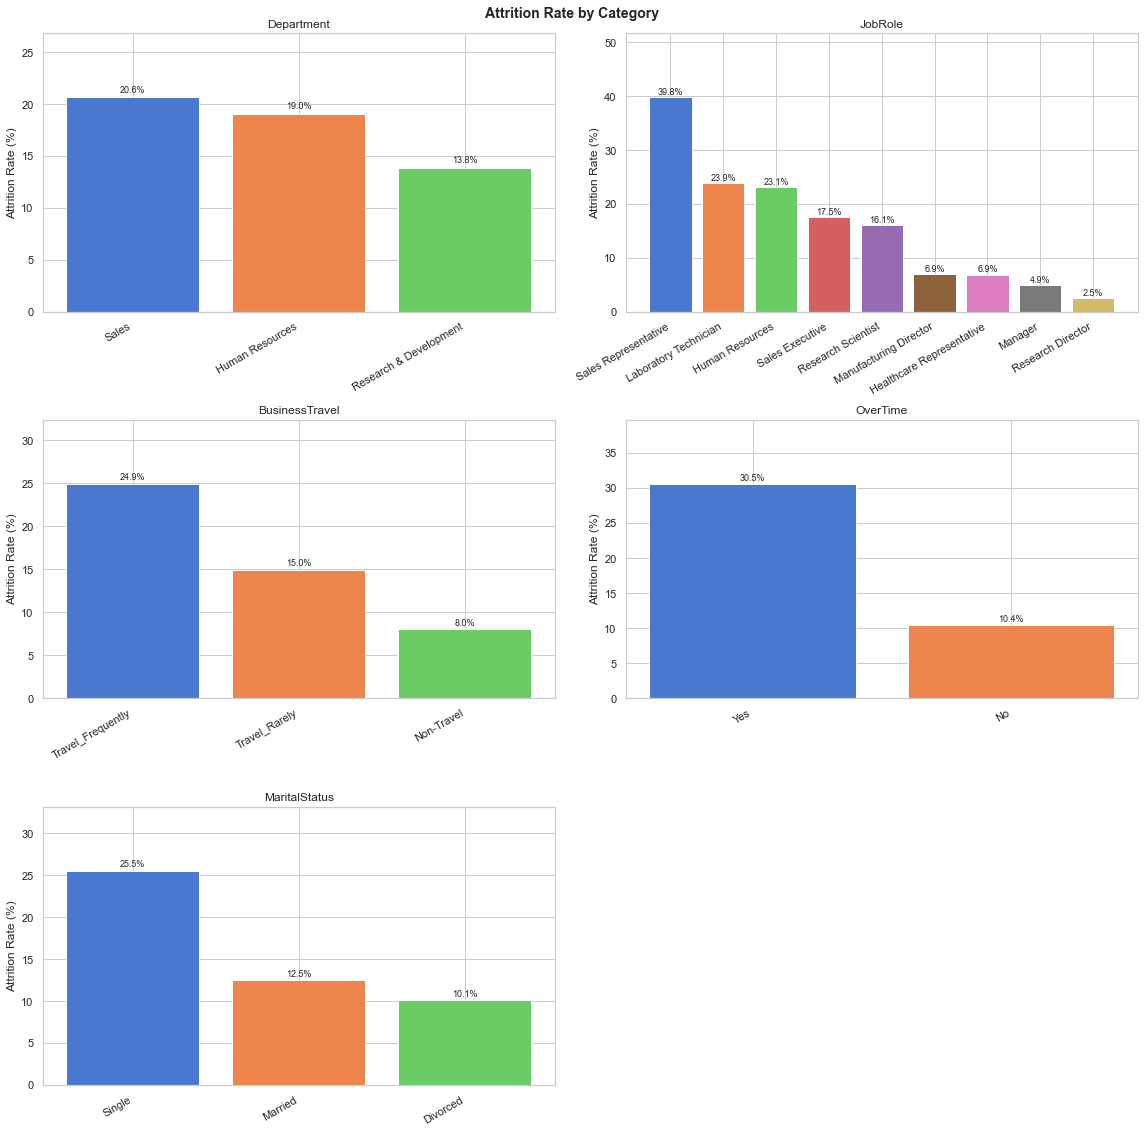

In [10]:
def plot_attrition_rate(col, ax, title=None):
    """Plot attrition rate (%) for each category in a column."""
    rates = (df.groupby(col)['Attrition']
               .apply(lambda x: (x == 'Yes').mean() * 100)
               .sort_values(ascending=False))
    
    bars = ax.bar(rates.index.astype(str), rates.values,
                  color=sns.color_palette('muted', len(rates)))
    ax.set_title(title or col)
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xlabel('')
    ax.set_ylim(0, rates.max() * 1.3)
    
    # Add percentage labels
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

cat_cols = ['Department', 'JobRole', 'BusinessTravel', 'OverTime', 'MaritalStatus']
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_attrition_rate(col, axes[i])

axes[-1].axis('off')  # Hide unused subplot
plt.suptitle('Attrition Rate by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

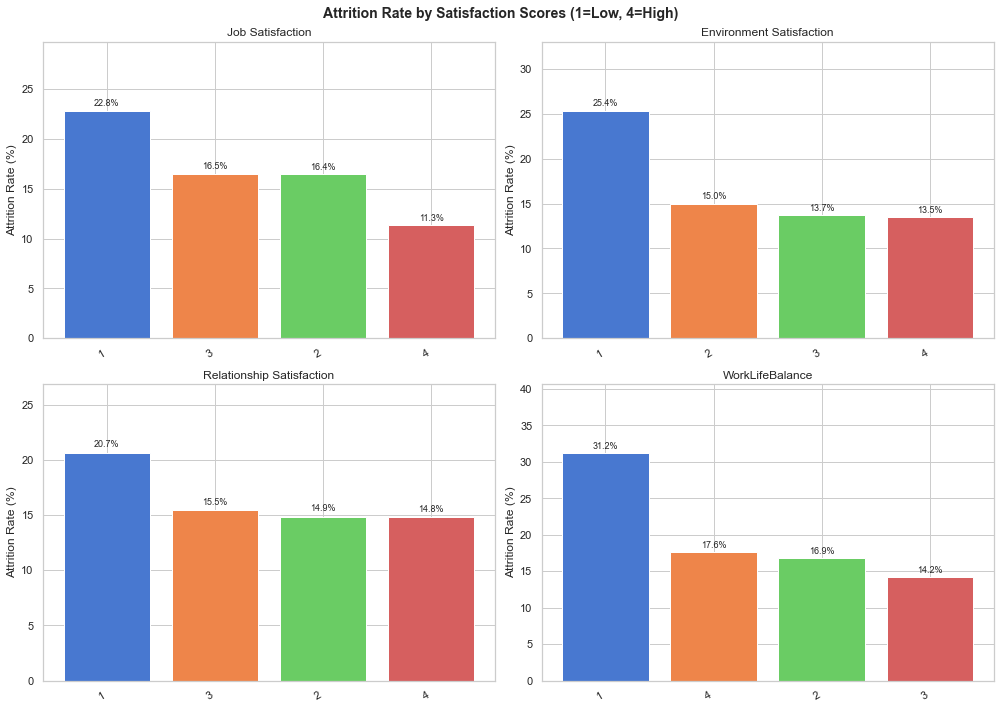

In [11]:
# Satisfaction scores vs attrition
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(satisfaction_cols):
    plot_attrition_rate(col, axes[i], title=col.replace('Satisfaction', ' Satisfaction'))

plt.suptitle('Attrition Rate by Satisfaction Scores (1=Low, 4=High)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

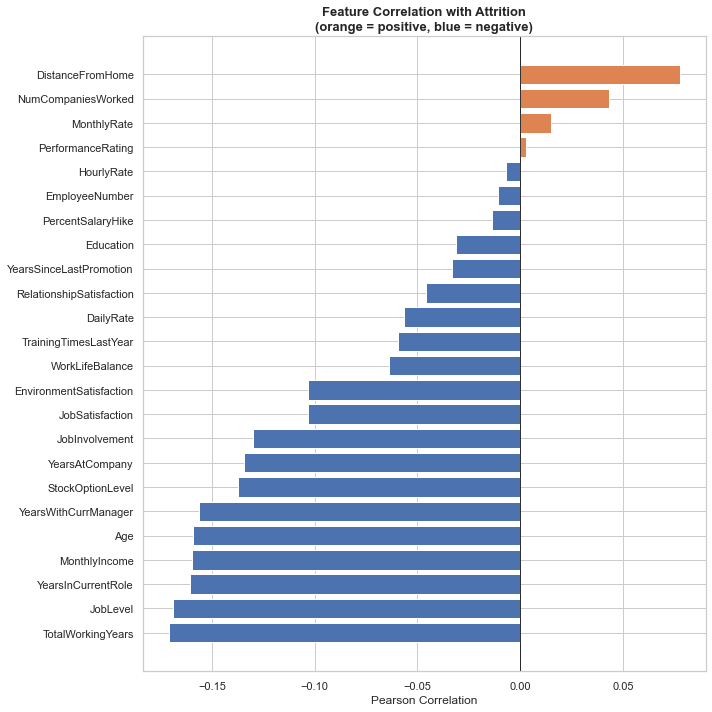

In [12]:
# Encode Attrition as binary for correlation
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)

# Select numeric columns and compute correlation with attrition
numeric_df = df.select_dtypes(include='number')
corr_with_attrition = (numeric_df.corr()['Attrition_binary']
                        .drop('Attrition_binary')
                        .sort_values()
                        .reset_index())
corr_with_attrition.columns = ['Feature', 'Correlation']

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in corr_with_attrition['Correlation']]
ax.barh(corr_with_attrition['Feature'], corr_with_attrition['Correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Attrition\n(orange = positive, blue = negative)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

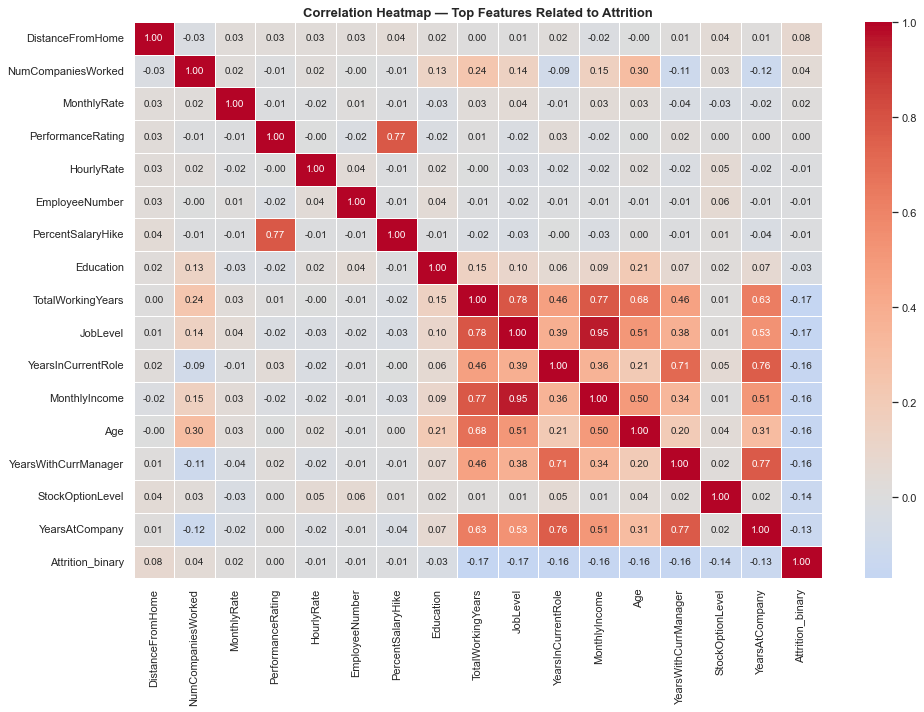

In [13]:
# Heatmap of most correlated numeric features
top_features = corr_with_attrition.nlargest(8, 'Correlation')['Feature'].tolist() + \
               corr_with_attrition.nsmallest(8, 'Correlation')['Feature'].tolist()
top_features.append('Attrition_binary')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top Features Related to Attrition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Business Conclusions

### Key Findings

**1. Overall attrition rate is ~16%**  
Out of 1,470 employees, 237 left the company — a significant cost given replacement costs of 50–200% of annual salary.

**2. Overtime is the strongest predictor**  
Employees who work overtime leave at 30.5% vs 10.4% for those who don't — roughly 3x higher. This is the single most actionable lever for HR.

**3. Low monthly income drives turnover**  
Employees who left earned ~30% less on average (≈$4,787 vs $6,833 monthly). Salary benchmarking and raises for bottom-quartile earners could reduce attrition.

**4. Young employees and early-career stages are highest risk**  
Employees who left are younger (avg. 34 vs 38) with fewer years at the company (avg. 5.1 vs 7.4) and lower job levels.

**5. Sales Representatives and Lab Technicians have critical attrition**  
Sales Representatives (39.8%) and Laboratory Technicians (23.9%) show the highest role-specific attrition — targeted retention programs are recommended.

---

### Recommended Actions for the Business

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| High | Limit mandatory overtime or compensate it better | Reduce attrition in overtime workers |
| High | Salary review for bottom 25% earners | Reduce income-driven turnover |
| Medium | Mentorship program for employees < 3 years at company | Improve early retention |
| Medium | Career path clarity for Sales Reps and Lab Technicians | Address role-specific turnover |
| Low | Work-life balance initiatives | Improve satisfaction scores |

---

### Next Steps
- Build a **classification model** (Logistic Regression / Random Forest) to predict individual attrition risk → see project `02_machine_learning/`
- Create an **interactive dashboard** to let HR managers explore these insights dynamically → see project `05_dashboard/`